# Lifetime Athlete Intelligence — the fun one

Uses **`lifetime_activities.csv`**: every activity you've ever recorded (all sports, all time). No date filter. Run `python src/build_lifetime_dataset.py` to generate it.

**Fun questions we answer:** What's your most (and rarest) activity type? Which gets the most kudos? Do harder workouts get more kudos?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/lifetime_activities.csv", parse_dates=["activity_date"])
df["year"] = df["activity_date"].dt.year
df["month"] = df["activity_date"].dt.to_period("M").astype(str)

# Filter to runs for run-specific charts later
runs = df[df["activity_type"].str.contains("run", case=False, na=False)].copy()

## Fun insights (all activities)

Answers: What's your most (and rarest) activity type? Which gets the most kudos? Do harder workouts get more kudos?

In [ ]:
# Most and rarest activity types (top 5 each)
type_counts = df["activity_type"].value_counts()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
# Left: most used = highest counts; reverse so #1 appears at top
type_counts.head(5).iloc[::-1].plot(kind="barh", ax=ax1, title="Top 5 most used activity types")
ax1.set_xlabel("Count")
# Right: rarest = lowest counts; reverse so rarest appears at top
type_counts.tail(5).iloc[::-1].plot(kind="barh", ax=ax2, title="Top 5 rarest activity types")
ax2.set_xlabel("Count")
plt.tight_layout()
plt.show()
print("Top 5 most used:", type_counts.head(5).to_dict())
print("Top 5 rarest:", type_counts.tail(5).to_dict())

In [ ]:
# Which activity type gets the most kudos?
if df["kudos"].notna().any():
    kudos_by_type = df.groupby("activity_type").agg(
        total_kudos=("kudos", "sum"),
        mean_kudos=("kudos", "mean"),
        count=("kudos", "count")
    ).query("count >= 3").sort_values("mean_kudos", ascending=False)
    if not kudos_by_type.empty:
        kudos_by_type.head(12).plot(y="mean_kudos", kind="barh", legend=False, title="Mean kudos by activity type (min 3 activities)")
        plt.xlabel("Mean kudos")
        plt.show()
        print(kudos_by_type.head(10))
    else:
        print("Not enough activities with kudos per type.")
else:
    print("No kudos column in this export (common for bulk export). Skip or use API data for kudos insights.")

In [ ]:
# Do harder workouts get more kudos?
has_kudos = df["kudos"].notna() if "kudos" in df.columns else pd.Series(False, index=df.index)
has_effort = df["relative_effort"].notna() if "relative_effort" in df.columns else pd.Series(False, index=df.index)
if has_kudos.any() and has_effort.any():
    sub = df.loc[has_kudos & has_effort, ["kudos", "relative_effort"]]
    plt.figure()
    plt.scatter(sub["relative_effort"], sub["kudos"], alpha=0.5)
    plt.xlabel("Relative effort")
    plt.ylabel("Kudos")
    plt.title("Do harder workouts get more kudos?")
    plt.show()
    print("Correlation (kudos vs relative_effort):", sub["kudos"].corr(sub["relative_effort"]))
else:
    print("Need both kudos and relative_effort in the dataset for this chart (often missing in bulk export).")

## Run-specific (from lifetime runs only)

The following charts use only runs from your lifetime dataset.

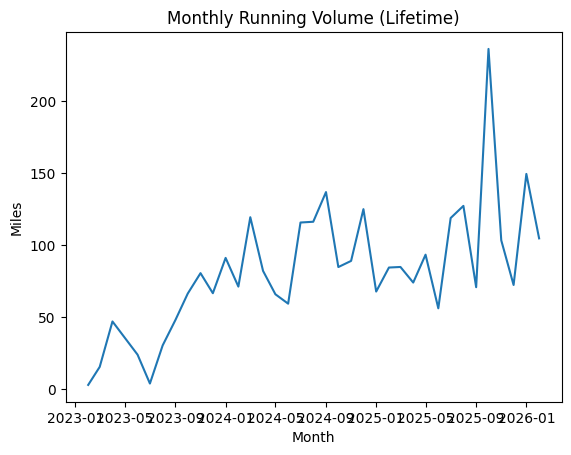

In [2]:
monthly = runs.groupby("month").agg(
    miles=("distance_mi", "sum"),
    runs=("activity_date", "count")
).reset_index()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(pd.to_datetime(monthly["month"] + "-01"), monthly["miles"])
ax.set_title("Monthly Running Volume (Lifetime)")
ax.set_xlabel("Month")
ax.set_ylabel("Miles")
# Fix crowded x-axis: show fewer ticks, rotate labels, format as Year-Mon
import matplotlib.dates as mdates
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Weeks 3+ and consistency index (below)**  
- **weeks**: Number of weeks in that year in which you had at least one run.  
- **weeks_3plus**: Number of weeks in that year in which you ran **at least 3 times**.  
- **consistency_index**: `weeks_3plus / weeks` (0–1). Higher means you ran 3+ times in more of the weeks you ran at all—a simple measure of run consistency for the year.

In [3]:
runs["week_start"] = (runs["activity_date"] - pd.to_timedelta(runs["activity_date"].dt.weekday, unit="D")).dt.normalize()

weekly_counts = runs.groupby(["year","week_start"]).size().reset_index(name="run_count")
yearly = weekly_counts.groupby("year").agg(
    weeks=("week_start","count"),
    weeks_3plus=("run_count", lambda x: (x >= 3).sum())
).reset_index()
yearly["consistency_index"] = yearly["weeks_3plus"] / yearly["weeks"]

yearly

,year,weeks,weeks_3plus,consistency_index
0,2023,34,14,0.411765
1,2024,49,40,0.816327
2,2025,47,39,0.829787
3,2026,8,8,1.000000


**Pace zones by year (below)**  
Count of runs in each pace zone (Easy, Moderate, Around MP, Faster than MP) per year. Zones are based on your goal marathon pace (e.g. 6:52/mi); “Around MP” is within a narrow band of that pace.

In [4]:
goal_mp_min = 6 + 52/60  # 6:52

def zone(p):
    if pd.isna(p):
        return "Unknown"
    if p <= goal_mp_min - 0.2:
        return "Faster than MP"
    if abs(p - goal_mp_min) <= 0.2:
        return "Around MP"
    if p <= goal_mp_min + 1.0:
        return "Moderate"
    return "Easy"

runs["pace_zone"] = runs["pace_min_mi"].apply(zone)

dist = runs.groupby(["year","pace_zone"]).size().reset_index(name="count")
pivot = dist.pivot(index="year", columns="pace_zone", values="count").fillna(0)

pivot

pace_zone,Around MP,Easy,Faster than MP,Moderate
year,,,,
2023,1.0,75.0,1.0,2.0
2024,2.0,149.0,5.0,23.0
2025,5.0,168.0,2.0,22.0
2026,1.0,27.0,0.0,5.0


**Best observed average pace over time**  
Each point is your **cumulative best** average pace (min/mi) up to that date—so the line only improves when you run a new PR. It naturally flattens as you get faster and PRs become rarer. The rolling average (dashed) smooths noise and shows the trend.

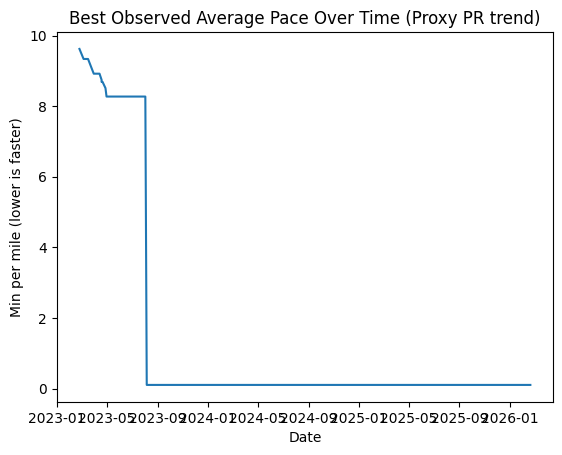

In [5]:
df = runs.dropna(subset=["pace_min_mi"]).sort_values("activity_date").copy()
df["best_pace_so_far"] = df["pace_min_mi"].cummin()
# Rolling average to show trend when line is flat
df["best_pace_rolling"] = df["best_pace_so_far"].rolling(30, min_periods=5).mean()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(df["activity_date"], df["best_pace_so_far"], alpha=0.7, label="Cumulative best")
ax.plot(df["activity_date"], df["best_pace_rolling"], linestyle="--", color="C1", label="30-run rolling")
ax.set_title("Best Observed Average Pace Over Time (lower = faster)")
ax.set_xlabel("Date")
ax.set_ylabel("Min per mile")
ax.legend(loc="best")
ax.invert_yaxis()
plt.tight_layout()
plt.show()